In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import re
import sys
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.preprocessing import StandardScaler
import torch
import heapq
# import hdbscan

In [35]:
# root_dir = Path(__file__).resolve().parent
root_dir = Path.cwd().parent
sys.path.insert(0, str(root_dir))
import beats_functions as beatsf

## BEATs clustering experiment

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_dir = r"E:\beats_extraction_samples"
extract_dir = r"E:\beats_extraction\Tracy_6230"
output_dir = r"E:\beats_experiment"

In [37]:
npz_files = list(Path(input_dir).rglob("*.npz"))
extract_files = list(Path(extract_dir).rglob("*.npz"))

rng = np.random.default_rng(104)
n_sample = min(100, len(extract_files))
extract_files_sample = rng.choice(extract_files, size=n_sample, replace=False).tolist()
files = npz_files + extract_files_sample

In [38]:
# X, meta = beatsf.beats_segs_from_embeddings(files, seg_sec=5.0, hop_sec=5.0, mode="pool")
# print("Shapes: ", X.shape, len(meta))

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)
# Z = X_scaled
# print(Z.shape)

In [39]:
# X_np = X.detach().numpy()
# mu = np.mean(X_np, axis=0)
# dists = np.linalg.norm(X_np - mu, axis=1)
# order = np.argsort(dists)[::-1]  # Ascending/descending order.

# top_k = 10
# print("Top candidate segments (most unusual in BEATs space):")
# for rank in range(top_k):
#     idx = order[rank]
#     file, s, e, seg_idx, sf, ef = meta[idx]
#     print(f"#{rank+1:02d}: seg {idx:03d}, t = [{s:.1f}, {e:.1f}] s, dist = {dists[idx]:.3f}, file = {file}")

In [40]:
# # Inertia curve.
# n_comps_list = [4, 8, 16, 32, 64, 128, 256]
# k_values = range(1, 16)
# inertias_ncomps = {}
# for n_comps in n_comps_list:
#     Z_ncomp = PCA(n_components=n_comps, random_state=104).fit_transform(Z)
#     inertias = []
#     for k in k_values:
#         kmeans = KMeans(n_clusters=k, random_state=104, n_init='auto')
#         kmeans.fit(Z_ncomp)
#         inertias.append(kmeans.inertia_)

#     inertias_ncomps[n_comps] = inertias

# fig, ax = plt.subplots(figsize=(8, 6))
# for n_comps in n_comps_list:
#     ax.plot(list(k_values), inertias_ncomps[n_comps], marker='o', label=f'PCA({n_comps})')
# ax.set_title('K-Means inertia curve')
# ax.set_xlabel('Number of Clusters (k)')
# ax.set_ylabel('Inertia')
# ax.legend()
# ax.grid(True)
# fig.tight_layout()
# plt.show()

In [41]:
# pca = PCA(n_components=16, random_state=104)
# Z_ncomp = pca.fit_transform(Z)
# print("PCA explained variance ratios:", pca.explained_variance_ratio_)

# k = 10
# kmeans = KMeans(n_clusters=k, random_state=104, n_init="auto")
# labels = kmeans.fit_predict(Z_ncomp)
# centers = kmeans.cluster_centers_

# pca2 = PCA(n_components=2)
# Z_2d = pca2.fit_transform(Z_ncomp)

# plt.figure(figsize=(8, 6))
# for j in range(k):
#     idx = (labels == j)
#     plt.scatter(Z_2d[idx, 0], Z_2d[idx, 1], label=f"Cluster {j}", alpha=0.7)

# plt.scatter(pca2.transform(centers)[:, 0], pca2.transform(centers)[:, 1],
#             s=50, c='brown', marker='x', label='Centroids')

# plt.title("KMeans Clustering of BEATs Segments (PCA-reduced)")
# plt.xlabel(f"PCA Component 1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)")
# plt.ylabel(f"PCA Component 2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)")
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()

In [42]:
# for j in range(k):
#     idx = np.where(labels == j)[0]
#     print(f"\nCluster {j} has {len(idx)} segments")
#     for n in idx[:10]: # Show n examples.
#         print(f"  seg {n:03d}: {meta[n]}")

In [43]:
# val_file1 = "6230.220917120000"
# val_file2 = "6230.221003000000"

# cols = ['file_id', 't0', 't1', 'seg_idx', 'sf', 'ef']
# pattern = re.escape(val_file1) + "|" + re.escape(val_file2)
# df1 = pd.DataFrame(meta, columns=cols)
# df1["cluster"] = labels

# df1_val = df1[df1["file_id"].str.contains(pattern, regex=True, na=False)]
# df1_val.iloc[0:50]

## Flattened

In [44]:
# X_flat, meta_flat = beatsf.beats_segs_from_embeddings(files, seg_sec=5.0, hop_sec=5.0, mode="flat_segment")
# X_flat_scaled = scaler.fit_transform(X_flat)
# print("Shapes: ", X_flat.shape, len(meta_flat))

# Z_flat = X_flat_scaled.detach().numpy()
# print(Z_flat.shape)
# pca_flat = PCA(n_components=8)
# Z_ncomp_flat = pca_flat.fit_transform(Z_flat)
# print("PCA explained variance ratios:", pca_flat.explained_variance_ratio_)

In [45]:
# # Inertia curve.
# n_comps_list = [2, 4, 8, 16, 32, 64, 128]
# k_values = range(1, 16)
# inertias_ncomps = {}
# for n_comps in n_comps_list:
#     Z_ncomp = PCA(n_components=n_comps, random_state=104).fit_transform(Z_flat)
#     inertias = []
#     for k in k_values:
#         kmeans = KMeans(n_clusters=k, random_state=104, n_init='auto')
#         kmeans.fit(Z_ncomp)
#         inertias.append(kmeans.inertia_)

#     inertias_ncomps[n_comps] = inertias

# fig, ax = plt.subplots(figsize=(8, 6))
# for n_comps in n_comps_list:
#     ax.plot(list(k_values), inertias_ncomps[n_comps], marker='o', label=f'PCA({n_comps})')
# ax.set_title('K-Means inertia curve')
# ax.set_xlabel('Number of Clusters (k)')
# ax.set_ylabel('Inertia')
# ax.legend()
# ax.grid(True)
# fig.tight_layout()
# plt.show()

In [46]:
# k = 7
# kmeans = KMeans(n_clusters=k, random_state=104, n_init="auto")
# kmeans.fit(Z_ncomp_flat)
# labels = kmeans.labels_
# centers = kmeans.cluster_centers_

# pca2 = PCA(n_components=2)
# Z_2d_flat = pca2.fit_transform(Z_ncomp_flat)

# plt.figure(figsize=(8, 6))
# for j in range(k):
#     idx = (labels == j)
#     plt.scatter(Z_2d_flat[idx, 0], Z_2d_flat[idx, 1], label=f"Cluster {j}", alpha=0.7)
# plt.scatter(pca2.transform(centers)[:, 0], pca2.transform(centers)[:, 1],
#             s=30, c='brown', marker='x', label='Centroids')

# plt.title("KMeans Clustering of BEATs Segments (Flat Segment Mode, PCA-reduced)")
# plt.xlabel(f"PCA Component 1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)")
# plt.ylabel(f"PCA Component 2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)")
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()

In [47]:
# for j in range(k):
#     idx = np.where(labels == j)[0]
#     print(f"\nCluster {j} has {len(idx)} segments")
#     for n in idx[:10]: # Show n examples.
#         print(f"  seg {n:03d}: {meta_flat[n]}")

## Flattened batches

In [48]:
n_components = 1024
batch_size = 1024
scaler = StandardScaler(with_mean=True, with_std=True)
ipca = IncrementalPCA(n_components=n_components, batch_size=batch_size)

# (1) Fit scaler + PCA incrementally.
for Xb, _ in beatsf.iter_beats_segments_npz(files, mode="flat_segment", batch_size=batch_size):
    if Xb.shape[0] < n_components:
        continue
    Xb = Xb.astype(np.float32, copy=False)
    scaler.partial_fit(Xb)
    Xb_s = scaler.transform(Xb) # Scale batch.
    ipca.partial_fit(Xb_s)

print("Explained variance ratios:", ipca.explained_variance_ratio_)

# (2) Fit k-means on PCA features incrementally.
k = 8
mbk = MiniBatchKMeans(n_clusters=k, random_state=104, batch_size=batch_size)

for Xb, _ in beatsf.iter_beats_segments_npz(files, mode="flat_segment", batch_size=batch_size):
    Xb = Xb.astype(np.float32, copy=False)
    Xb_s = scaler.transform(Xb)
    Zb = ipca.transform(Xb_s).astype(np.float32, copy=False)
    mbk.partial_fit(Zb)

# (3) Collect labels.
mbk.cluster_centers_ = mbk.cluster_centers_.astype(np.float32, copy=False)
labels_all = []
meta_all = []
for Xb, metab in beatsf.iter_beats_segments_npz(files, mode="flat_segment", batch_size=batch_size):
    Xb = Xb.astype(np.float32, copy=False)
    Xs = scaler.transform(Xb)
    Zb = ipca.transform(Xs).astype(np.float32, copy=False)
    labels_all.append(mbk.predict(Zb))
    meta_all.extend(metab)

labels = np.concatenate(labels_all)


Explained variance ratios: [0.09266504 0.06594679 0.06557054 ... 0.00011076 0.00011065 0.00011025]


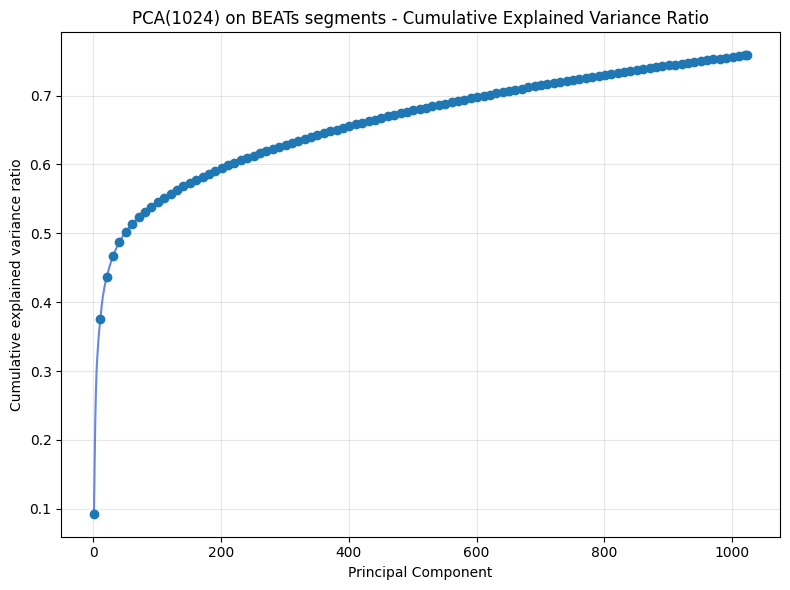

In [49]:
save_path = Path(r"C:\Users\Lindholm\Documents\BSc\bsc_project\graphs\week15_figures")
# Plot explained variance ratios.
evr = ipca.explained_variance_ratio_
x = np.arange(1, len(evr) + 1)
cev = np.cumsum(evr)
plt.figure(figsize=(8, 6))
plt.plot(x, cev, color="royalblue", alpha=0.8)
step = 10
idx = np.r_[np.arange(0, len(x), step), len(x) - 1]
idx = np.unique(idx)
plt.plot(x[idx], cev[idx], marker="o", linestyle="None")
plt.xlabel('Principal Component')
plt.ylabel('Cumulative explained variance ratio')
plt.title(f'PCA({ipca.n_components_}) on BEATs segments - Cumulative Explained Variance Ratio')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(save_path / f"pca{ipca.n_components_}_cumulative_explained_variance.png", dpi=300)
plt.show()

In [50]:
# (4) Collect Z (needed for PCA(2) and top-n nearest).
Z_all = []
for Xb, _ in beatsf.iter_beats_segments_npz(files, mode="flat_segment", batch_size=batch_size):
    Xb = Xb.astype(np.float32, copy=False)
    Zb = ipca.transform(scaler.transform(Xb)).astype(np.float32, copy=False)
    Z_all.append(Zb)

Z = np.vstack(Z_all) # (N, n_components).
centers = mbk.cluster_centers_.astype(np.float32, copy=False)

# PCA(2) for visualization (on Z, not on raw flat segments)
pca2 = PCA(n_components=2, random_state=104)
Z2 = pca2.fit_transform(Z)
C2 = pca2.transform(centers)

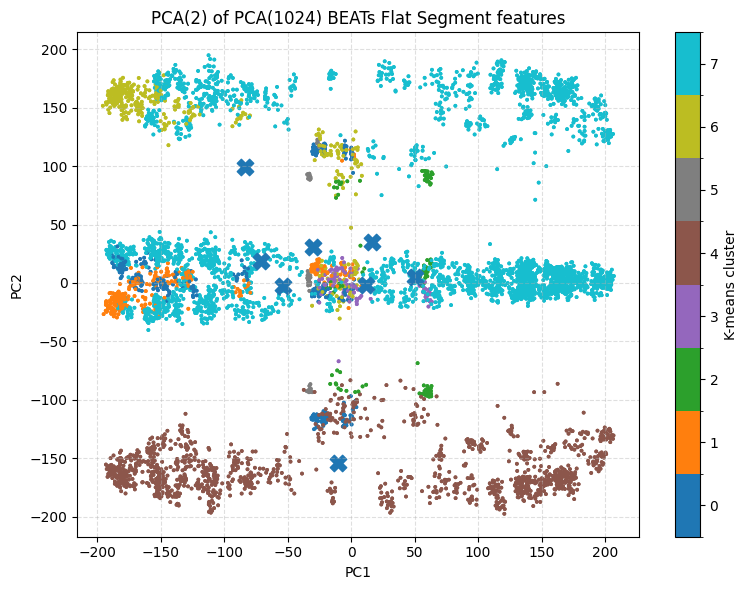

In [51]:
k_plt = int(labels.max()) + 1 
cmap = plt.get_cmap("tab10", k_plt)
bounds = [-0.5] + [i + 0.5 for i in range(k_plt)]
norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)
plt.figure(figsize=(8, 6))
plt.scatter(Z2[:, 0], Z2[:, 1], c=labels, s=3, cmap=cmap, norm=norm)
sc = plt.scatter(Z2[:, 0], Z2[:, 1], c=labels, s=3, cmap=cmap, norm=norm)
plt.scatter(C2[:, 0], C2[:, 1], marker="X", s=140)
cbar = plt.colorbar(sc, ticks=range(k), boundaries=bounds)
cbar.set_label("K-means cluster")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"PCA(2) of PCA({ipca.n_components_}) BEATs Flat Segment features")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [52]:
def topn_near_centroids_stream(files, scaler, ipca, centers, iter_fn,
                               topn=15, batch_size=256):
    k = centers.shape[0]
    heaps = [[] for _ in range(k)]  # store (-d2, global_idx, meta)
    global_idx = 0

    for Xb, metab in iter_fn(files, mode="flat_segment", batch_size=batch_size):
        Xb = Xb.astype(np.float32, copy=False)
        Zb = ipca.transform(scaler.transform(Xb)).astype(np.float32, copy=False)

        # squared distances to all centers: (B, k)
        d2 = (Zb[:, None, :] - centers[None, :, :])
        d2 = np.einsum("bkd,bkd->bk", d2, d2)

        for i in range(Zb.shape[0]):
            c = int(np.argmin(d2[i]))
            di2 = float(d2[i, c])
            item = (-di2, global_idx, metab[i])

            h = heaps[c]
            if len(h) < topn:
                heapq.heappush(h, item)
            else:
                if item[0] > h[0][0]:  # better (smaller d2)
                    heapq.heapreplace(h, item)

            global_idx += 1

    # sorted results per cluster: [(dist2, global_idx, meta), ...]
    results = []
    for c in range(k):
        items = [(-neg_d2, idx, meta) for (neg_d2, idx, meta) in heaps[c]]
        items.sort(key=lambda x: x[0])
        results.append(items)
    return results

centers = mbk.cluster_centers_.astype(np.float32, copy=False)
top_hits = topn_near_centroids_stream(
    files, scaler, ipca, centers, beatsf.iter_beats_segments_npz,
    topn=10, batch_size=batch_size
)

all_hits = [(c, dist2, idx, m) for c, hits in enumerate(top_hits) for dist2, idx, m in hits]
all_hits.sort(key=lambda x: x[1])  # by distance

In [53]:
rows = []
for c, dist2, idx, m in all_hits:
    file_id, t0, t1, seg_idx, sf, ef = m
    rows.append({
        "cluster": c,
        "dist2": dist2,
        "global_idx": idx,
        "file_id": str(file_id),
        "filename": Path(str(file_id)).name,
        "t0": t0,
        "t1": t1,
        "seg_idx": seg_idx,
        "sf": sf,
        "ef": ef,
    })

df_hits = pd.DataFrame(rows).sort_values(["cluster", "dist2"]).reset_index(drop=True)
df_hits.head(5)

,cluster,dist2,global_idx,file_id,filename,t0,t1,seg_idx,sf,ef
0,0,41365.960938,107,D:\data_dryad\Aug_6229\6229.220802130000.wav,6229.220802130000.wav,15.011329,20.015106,107,750,1000
1,0,41614.164062,151,D:\data_dryad\Aug_6229\6229.220802130000.wav,6229.220802130000.wav,235.177492,240.181269,151,11750,12000
2,0,42006.179688,147,D:\data_dryad\Aug_6229\6229.220802130000.wav,6229.220802130000.wav,215.162387,220.166163,147,10750,11000
3,0,42022.425781,111,D:\data_dryad\Aug_6229\6229.220802130000.wav,6229.220802130000.wav,35.026435,40.030211,111,1750,2000
4,0,42247.128906,139,D:\data_dryad\Aug_6229\6229.220802130000.wav,6229.220802130000.wav,175.132175,180.135952,139,8750,9000


In [54]:
df_top10 = df_hits.groupby("cluster", as_index=False).head(10)
df_top10.iloc[0:35]

,cluster,dist2,global_idx,file_id,filename,t0,t1,seg_idx,sf,ef
0,0,41365.960938,107,D:\data_dryad\Aug_6229\6229.220802130000.wav,6229.220802130000.wav,15.011329,20.015106,107,750,1000
1,0,41614.164062,151,D:\data_dryad\Aug_6229\6229.220802130000.wav,6229.220802130000.wav,235.177492,240.181269,151,11750,12000
2,0,42006.179688,147,D:\data_dryad\Aug_6229\6229.220802130000.wav,6229.220802130000.wav,215.162387,220.166163,147,10750,11000
3,0,42022.425781,111,D:\data_dryad\Aug_6229\6229.220802130000.wav,6229.220802130000.wav,35.026435,40.030211,111,1750,2000
4,0,42247.128906,139,D:\data_dryad\Aug_6229\6229.220802130000.wav,6229.220802130000.wav,175.132175,180.135952,139,8750,9000
5,0,42718.906250,131,D:\data_dryad\Aug_6229\6229.220802130000.wav,6229.220802130000.wav,135.101964,140.105740,131,6750,7000
6,0,43185.546875,143,D:\data_dryad\Aug_6229\6229.220802130000.wav,6229.220802130000.wav,195.147281,200.151057,143,9750,10000
7,0,43227.875000,123,D:\data_dryad\Aug_6229\6229.220802130000.wav,6229.220802130000.wav,95.071752,100.075529,123,4750,5000
8,0,43444.207031,271,D:\data_dryad\Aug_6229\6229.220802140000.wav,6229.220802140000.wav,55.041541,60.045317,271,2750,3000
9,0,43651.632812,283,D:\data_dryad\Aug_6229\6229.220802140000.wav,6229.220802140000.wav,115.086858,120.090634,283,5750,6000


In [55]:
df_hits[df_hits["filename"].str.contains("6230.220917120000", na=False)]

,cluster,dist2,global_idx,file_id,filename,t0,t1,seg_idx,sf,ef


In [56]:
df_hits[df_hits["filename"].str.contains("6230.221003000000", na=False)]

,cluster,dist2,global_idx,file_id,filename,t0,t1,seg_idx,sf,ef


In [57]:
hdb_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
)
hdb_labels = hdb_clusterer.fit_predict(Z.astype(np.float32, copy=False))

NameError: name 'hdbscan' is not defined

In [ ]:
# snap_path = r"E:\beats_experiment\pca_model_ncomps128\beats_models_snapshot.npz"

# # --- load snapshot ---
# with np.load(snap_path, allow_pickle=False) as z:
#     mean_  = z["scaler_mean"]
#     scale_ = z["scaler_scale"]
#     comps  = z["ipca_components"]      # (n_components, D_in)
#     ipca_mu = z["ipca_mean"]           # (D_in,)
#     centers = z["kmeans_centers"]      # (k, n_components)
#     k = int(z["k"])

# # --- helpers: apply scaler + (incremental) PCA using saved params ---
# def scale_batch(X, mean, scale):
#     # StandardScaler transform: (X - mean) / scale
#     return (X - mean) / scale

# def ipca_transform_batch(Xs, ipca_mean, components):
#     # sklearn PCA/IPCA transform: (Xs - ipca_mean) @ components.T
#     return (Xs - ipca_mean) @ components.T

# def assign_clusters(Z, centers):
#     # squared euclidean to centers, then argmin
#     # d2 = ||z||^2 + ||c||^2 - 2 z·c
#     zz = np.sum(Z * Z, axis=1, keepdims=True)              # (B,1)
#     cc = np.sum(centers * centers, axis=1)[None, :]        # (1,k)
#     d2 = zz + cc - 2.0 * (Z @ centers.T)                   # (B,k)
#     return np.argmin(d2, axis=1).astype(np.int32)

# # --- stream, compute Z + labels (optionally subsample for plotting) ---
# Z_list = []
# y_list = []

# max_points = 200_000   # avoid plotting millions; adjust
# seen = 0

# for Xb, _ in beatsf.iter_beats_segments_npz(files, mode="flat_segment", batch_size=256):
#     Xb = Xb.astype(np.float32, copy=False)

#     Xs = scale_batch(Xb, mean_, scale_).astype(np.float32, copy=False)
#     Zb = ipca_transform_batch(Xs, ipca_mu, comps).astype(np.float32, copy=False)
#     yb = assign_clusters(Zb, centers)

#     Z_list.append(Zb)
#     y_list.append(yb)

#     seen += Zb.shape[0]
#     if seen >= max_points:
#         break

# Z = np.vstack(Z_list)
# labels = np.concatenate(y_list)

# # --- PCA(2) just for visualization ---
# pca2 = PCA(n_components=2, random_state=104)
# Z2 = pca2.fit_transform(Z)

# plt.figure(figsize=(8, 6))
# plt.scatter(Z2[:, 0], Z2[:, 1], c=labels, s=3)
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.title("PCA(2) of IPCA(128) BEATs features")
# plt.grid(True, linestyle="--", alpha=0.4)
# plt.tight_layout()
# plt.show()

In [ ]:
# n_comps_list = [2, 4, 8, 16, 32, 64, 128]
# k_values = range(1, 16)

# inertias_ncomps = beatsf.elbow_streaming_ipca_kmeans(
#     files,
#     n_comps_list=n_comps_list,
#     k_values=k_values,
#     seg_sec=5.0,
#     hop_sec=5.0,
#     mode="flat_segment",
#     batch_size=256,
#     random_state=104,
#     file_duration_sec=265.0,
# )

# fig, ax = plt.subplots(figsize=(8, 6))
# for n_comps in n_comps_list:
#     ax.plot(list(k_values), inertias_ncomps[n_comps], marker="o", label=f"IPCA({n_comps})")
# ax.set_title("K-Means inertia curve (streaming)")
# ax.set_xlabel("Number of clusters (k)")
# ax.set_ylabel("Inertia (SSE)")
# ax.grid(True)
# ax.legend()
# fig.tight_layout()
# plt.show()